In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.ticker as ticker
plt.style.use('seaborn-v0_8-whitegrid')

from src.testcases.fourier import exact_solution

In [2]:
path = "lbm_fourier_20251124_223715.npz"  # gaussian

data = np.load(path, allow_pickle=True)

meta = data["meta"].item()
config = meta["config"]
#print(config)

qtm_traj = data["quantum_traj"].item()
qtm_F = qtm_traj["F"]
qtm_rho = qtm_traj["rho"]
qtm_u = qtm_traj["u"]

cls_traj = data["classical_traj"].item()
cls_F = cls_traj["F"]
cls_rho = cls_traj["rho"]
cls_u = cls_traj["u"]

In [3]:
print(config["u0"])
print(config["u_adv"])

time-dependent function
time-dependent function


In [4]:
n_frames = qtm_rho.shape[0]
exact_rho_t = exact_solution(C0=config["C0"], C1=config["C1"], u_max=config["u_max"], mu=config["mu"])
exact_rho = np.array([exact_rho_t(t) for t in 20*np.arange(n_frames)])

In [5]:
## Density (Scalar) error
qtm_exact_er = abs(qtm_rho - exact_rho)
qtm_cls_er = abs(cls_rho - exact_rho)

abs_cls_rho = abs(cls_rho)
abs_exact_rho = abs(exact_rho)
abs_qtm_rho = abs(qtm_rho)

qtm_exact_rel = np.sum(qtm_exact_er, axis=(1,)) / np.sum(abs_exact_rho, axis=(1,))
qtm_cls_rel = np.sum(qtm_cls_er, axis=(1,)) / np.sum(abs_cls_rho, axis=(1,))

print(qtm_exact_rel)



[5.85469173e-17 1.01723356e-04 2.02247835e-04 3.01560443e-04
 3.99687643e-04 4.96673833e-04 5.92503369e-04 6.87201284e-04
 7.80739699e-04 8.73121624e-04 9.64351805e-04 1.05446654e-03
 1.14355325e-03 1.23167224e-03 1.31870723e-03 1.40465995e-03
 1.48954073e-03 1.57336142e-03 1.65613520e-03 1.73787643e-03
 1.81866368e-03 1.89845907e-03 1.97726714e-03 2.05511251e-03
 2.13203289e-03 2.20799845e-03 2.28302002e-03 2.35710682e-03
 2.43026598e-03 2.50250198e-03 2.57382323e-03 2.64429484e-03
 2.71386187e-03 2.78251490e-03 2.85036974e-03 2.91737424e-03
 2.98350149e-03 3.04880497e-03 3.11324300e-03 3.17673215e-03
 3.23979450e-03 3.30191064e-03 3.36321936e-03 3.42335302e-03
 3.48317676e-03 3.54232984e-03 3.60043087e-03 3.65760703e-03
 3.71454826e-03 3.77043092e-03 3.82556751e-03 3.88024601e-03
 3.93394646e-03 3.98709709e-03 4.03949020e-03 4.09126117e-03
 4.14221955e-03 4.19270015e-03 4.24225016e-03 4.29144948e-03
 4.33953021e-03 4.38755776e-03 4.43458625e-03 4.48106161e-03
 4.52703363e-03 4.572066

In [6]:
T = 10001
grid_size, C0, C1, u_max, mu, D = config["grid_size"], config["C0"], config["C1"], config["u_max"], config["mu"], config["D"]

L = grid_size[0]
k = 2 * np.pi / L  # wave number

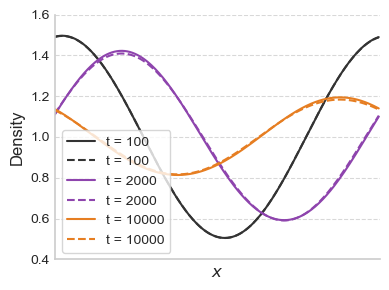

In [7]:
t_range = np.array([T//10, T//5, T])

y_envelop_h = C0 + C1 * np.exp(-D * k**2 * np.arange(0, T))
y_envelop_l = C0 - C1 * np.exp(-D * k**2 * np.arange(0, T))


fig, ax = plt.subplots(figsize=(4, 3))
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.set_xlim(0,L)
ax.set_ylim(0.4,1.6)

ax.set_xticks([])
ax.tick_params(axis='both', labelsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')
ax.grid(axis='x', visible=False) # Keep x-grid off as requested

# 4. Plot the wave at different time steps
times = [100, 2000, 10000]
#colors = ['black', 'purple', 'orange']
colors = ['#333333', '#8E44AD', '#E67E22']


#colors = cm.plasma(np.linspace(0, 0.85, len(times)))

for t, c in zip(times, colors):

    ax.plot(range(L), abs_qtm_rho[t//20], label=f't = {t}', color=c, linewidth=1.5)

    ax.plot(range(L), abs_exact_rho[t//20], label=f't = {t}', color=c, linewidth=1.5, linestyle='--')
    # Optional: Plot the envelop for this specific time step
    #ax.fill_between(range(L), y_envelop_h[t], y_envelop_l[t], color=c, alpha=0.1, zorder=3)

ax.legend(loc="lower left", frameon=True, fontsize=10)
ax.set_ylabel("Density", fontsize=12)
ax.set_xlabel(f"$x$", fontsize=12)
plt.tight_layout()
plt.savefig("fourier_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()


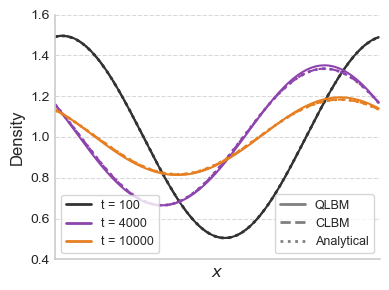

In [17]:
from matplotlib.lines import Line2D

t_range = np.array([T//10, T//5, T])

y_env = np.exp(-D * k**2 * np.arange(T))
y_env_h = C0 + C1 * y_env
y_env_l = C0 - C1 * y_env

fig, ax = plt.subplots(figsize=(4, 3))

for spine in ('right', 'top'):
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.set_xlim(0, L)
ax.set_ylim(0.4, 1.6)
ax.set_xticks([])
ax.tick_params(labelsize=10)

ax.grid(axis='y', linestyle='--', alpha=0.3, color='gray')

times  = [100, 4000, 10000]
colors = ['#333333', '#8E44AD', '#E67E22']

for t, c in zip(times, colors):
    idx = t // 20
    ax.plot(range(L), abs_qtm_rho[idx],   color=c, lw=1.5)               # QLBM
    ax.plot(range(L), abs_cls_rho[idx],   color=c, lw=1.5, ls='--')      # CLBM
    ax.plot(range(L), abs_exact_rho[idx], color=c, lw=2., ls=':')      # Exact

# ---------- legend system ----------
# legend 1: timestamps (color meaning)
ts_handles = [
    Line2D([0], [0], color='#333333', lw=2),
    Line2D([0], [0], color='#8E44AD', lw=2),
    Line2D([0], [0], color='#E67E22', lw=2),
]
ts_labels = ['t = 100', 't = 4000', 't = 10000']

legend_ts = ax.legend(
    ts_handles,
    ts_labels,
    #title="Timestamps",
    loc="lower left",
    frameon=True,
    fontsize=9,
)

# legend 2: category (line style meaning)
cat_handles = [
    Line2D([0], [0], color='gray', lw=2),
    Line2D([0], [0], color='gray', lw=2, ls='--'),
    Line2D([0], [0], color='gray', lw=2, ls=':')
]
cat_labels = ['QLBM', 'CLBM', "Analytical"]

legend_cat = ax.legend(
    cat_handles,
    cat_labels,
    #title="Method",
    loc="lower right",
    frameon=True,
    fontsize=9,
)

ax.add_artist(legend_ts)

ax.set_ylabel("Density", fontsize=12)
ax.set_xlabel("$x$", fontsize=12)

plt.tight_layout()
plt.savefig("fourier_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()


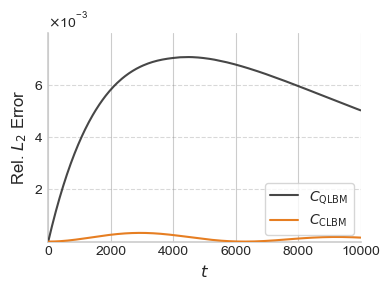

In [12]:
fig, ax = plt.subplots(figsize=(4, 3)) # dpi=150 makes it crisp for screens

# 2. Spines: Instead of coloring them gray, remove top/right entirely
# This is the standard "Tufte" minimalist style for scientific plots
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

# 3. Axis Formatting
ax.set_xlim(0,T)
ax.set_ylim(0, 8e-3)
# Force Scientific Notation (e.g., 1.5 x 10^-3) to clean up the Y-axis labels
formatter = ticker.ScalarFormatter(useMathText=True)
formatter.set_scientific(True)
formatter.set_powerlimits((-2, 2))
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.get_offset_text().set_fontsize(10)

ax.set_yticks(np.array([2., 4., 6.]) * 1e-3)

ax.tick_params(axis='both', labelsize=10)

# 4. Grid: A subtle horizontal grid helps read amplitude without clutter
ax.grid(visible=True, axis='y', linestyle='--', alpha=0.3, color='gray')

# 5. Plotting
# 'zorder' ensures lines are drawn on top of the grid
# 'alpha' on the black line softens it slightly so it's not too harsh
times = np.arange(0,T,20)

ax.plot(times, qtm_exact_rel, label='$C_{\\text{QLBM}}$',
        color='#333333', linewidth=1.5, alpha=0.9, zorder=3)

ax.plot(times, qtm_cls_rel, label='$C_{\\text{CLBM}}$',
        color='#E67E22', linewidth=1.5, zorder=3)

#FF8C00
# 6. Labels and Legend
ax.set_xlabel('$t$', fontsize=12)
ax.set_ylabel('Rel. $L_2$ Error', fontsize=12)

# "frameon=False" removes the box around the legend for a cleaner look
ax.legend(loc='lower right', frameon=True, fontsize=10)

plt.tight_layout()
plt.savefig("fourier_error.pdf", format="pdf", bbox_inches="tight")

plt.show()